In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/luisjaneirobezi/hotel-bookings/hotel_bookings.csv


# Limpieza y filtro de demanda real por segmento

In [2]:
# ================================
# LIBRERÍAS
# ================================

import pandas as pd

# ================================
# CARGAR DATASET
# ================================

df = pd.read_csv("/kaggle/input/datasets/luisjaneirobezi/hotel-bookings/hotel_bookings.csv")

# ================================
# LIMPIEZA BÁSICA
# ================================

df["market_segment"] = df["market_segment"].str.strip().fillna("Unknown")

# ================================
# ROOM NIGHTS
# ================================

df["room_nights"] = (
    df["stays_in_weekend_nights"] +
    df["stays_in_week_nights"]
)

# ================================
# SOLO DEMANDA REAL
# ================================

df_real = df[df["is_canceled"] == 0].copy()

# ================================
# VARIABLE FECHA
# ================================

df_real["arrival_date"] = pd.to_datetime(
    df_real["arrival_date_year"].astype(str)
    + "-"
    + df_real["arrival_date_month"]
    + "-"
    + df_real["arrival_date_day_of_month"].astype(str)
)

df_real["month"] = df_real["arrival_date"].dt.to_period("M").dt.to_timestamp()

# ================================
# DEMANDA REAL MENSUAL POR SEGMENTO
# ================================

demand_real = (
    df_real
    .groupby(["month","market_segment"])["room_nights"]
    .sum()
    .reset_index()
)

# ordenar para series temporales
demand_real = demand_real.sort_values(["market_segment","month"])

print(demand_real.head())

        month market_segment  room_nights
42 2016-02-01       Aviation            4
49 2016-03-01       Aviation            4
56 2016-04-01       Aviation           86
63 2016-05-01       Aviation          161
70 2016-06-01       Aviation           13


# Forecast demanda del total del hotel

15:42:12 - cmdstanpy - INFO - Chain [1] start processing
15:42:24 - cmdstanpy - INFO - Chain [1] done processing
15:42:25 - cmdstanpy - INFO - Chain [1] start processing


MAPE Total Hotel: 5.89 %

Real vs Forecast
           ds      y      forecast
23 2017-06-01  11739  11054.828857
24 2017-07-01  12469  11087.177078
25 2017-08-01  12135  12043.268693


15:42:26 - cmdstanpy - INFO - Chain [1] done processing



Forecast próximos 3 meses:
           ds          yhat
26 2017-09-01  12904.893843
27 2017-10-01  12416.713344
28 2017-11-01   8966.595916


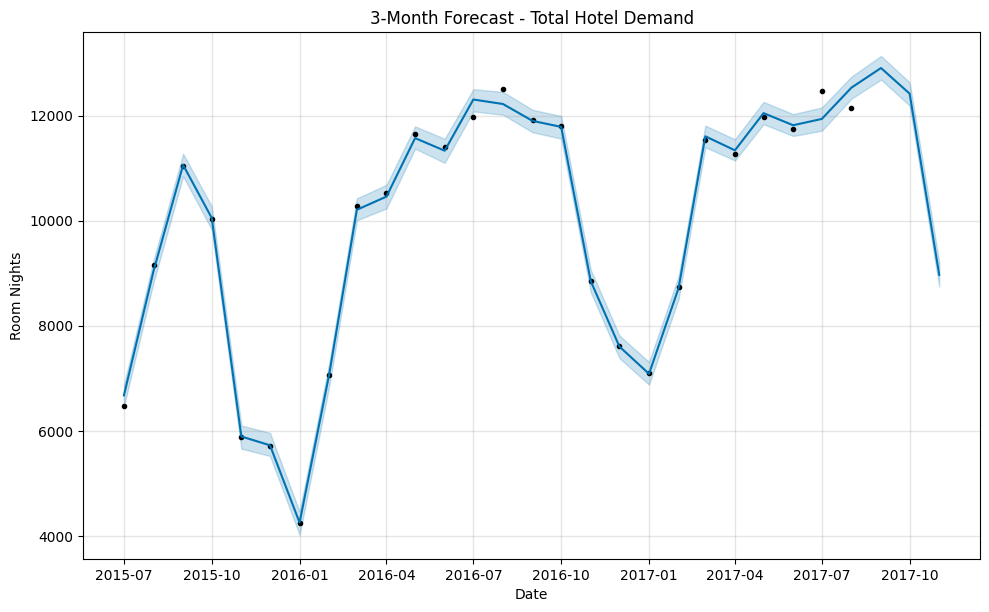

In [3]:
# ================================
# LIBRERÍAS
# ================================

import pandas as pd
from prophet import Prophet
from sklearn.metrics import mean_absolute_percentage_error
import matplotlib.pyplot as plt

# ================================
# DEMANDA TOTAL DEL HOTEL
# ================================

total_demand = (
    demand_real
    .groupby("month")["room_nights"]
    .sum()
    .reset_index()
)

# formato prophet
total_demand = total_demand.rename(columns={
    "month": "ds",
    "room_nights": "y"
})

total_demand = total_demand.sort_values("ds")

# ================================
# TRAIN / TEST SPLIT (3 MESES)
# ================================

train = total_demand.iloc[:-3]
test = total_demand.iloc[-3:]

# ================================
# MODELO PROPHET
# ================================

model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

model.fit(train)

# ================================
# FORECAST VALIDACIÓN
# ================================

future = model.make_future_dataframe(
    periods=3,
    freq="MS"
)

forecast = model.predict(future)

pred = forecast[["ds","yhat"]].tail(3)

# ================================
# MÉTRICA MAPE
# ================================

mape = mean_absolute_percentage_error(test["y"], pred["yhat"])

print("MAPE Total Hotel:", round(mape*100,2), "%")

# ================================
# COMPARACIÓN REAL VS FORECAST
# ================================

comparison = test.copy()
comparison["forecast"] = pred["yhat"].values

print("\nReal vs Forecast")
print(comparison)

# ================================
# MODELO FINAL CON TODO EL HISTÓRICO
# ================================

final_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

final_model.fit(total_demand)

# ================================
# FORECAST FUTURO
# ================================

future_final = final_model.make_future_dataframe(
    periods=3,
    freq="MS"
)

forecast_final = final_model.predict(future_final)

print("\nForecast próximos 3 meses:")
print(forecast_final[["ds","yhat"]].tail(3))

# ================================
# VISUALIZACIÓN
# ================================

fig = final_model.plot(forecast_final)

plt.title("3-Month Forecast - Total Hotel Demand")
plt.xlabel("Date")
plt.ylabel("Room Nights")

plt.show()

# Tabla comparativa — Demanda Total del Hotel
| Mes        | Demanda 2016 | Forecast 2017 | Diferencia | Incremento % |
| ---------- | ------------ | ------------- | ---------- | ------------ |
| Septiembre | 12000        | 12904         | +904       | **+7.5%**    |
| Octubre    | 11800        | 12416         | +616       | **+5.2%**    |
| Noviembre  | 8900         | 8967          | +67        | **+0.8%**    |

El forecast indica crecimiento moderado del hotel respecto al año anterior, pero con un patrón interesante.

1️⃣ Crecimiento fuerte tras temporada alta

Septiembre muestra el mayor incremento (~7.5%). Esto sugiere que la demanda posterior al verano podría estar más fuerte que el año anterior.

Esto suele ocurrir cuando:

aumenta la demanda internacional

el hotel gana visibilidad online

el mix de canales mejora.

2️⃣ Crecimiento más moderado en octubre

El incremento baja a ~5%. Esto indica estabilidad de la demanda, sin grandes cambios estructurales.

3️⃣ Demanda prácticamente plana en noviembre

El crecimiento es casi nulo (~0.8%), lo que sugiere que la temporada baja mantiene niveles similares al año anterior.

# Conclusión estratégica

El forecast sugiere que el hotel experimentará un crecimiento moderado en la demanda total respecto al año anterior, especialmente durante el periodo posterior a la temporada alta. La mayor mejora se observa en septiembre, mientras que octubre muestra estabilidad y noviembre mantiene niveles similares a los del año previo.

Desde una perspectiva de Revenue Management, este escenario indica una oportunidad para optimizar el ADR en los meses de mayor crecimiento, especialmente en septiembre, mientras que en noviembre podría ser necesario implementar estrategias de estimulación de demanda para evitar una desaceleración en temporada baja.

# Filtros para modelos de Forecasting por Segmento



# Filtro 1 — Volumen mínimo 

Si un segmento tiene muy poca demanda, cualquier modelo tendrá errores enormes.

Regla muy usada en forecasting comercial:

volumen anual	decisión
< 5k room nights	no modelar
5k–20k	cuidado

20k | viable |

In [4]:
segment_volume = (
    demand_real
    .groupby("market_segment")["room_nights"]
    .sum()
    .sort_values(ascending=False)
)

print(segment_volume)

market_segment
Online TA        119080
Offline TA/TO     67815
Direct            32849
Groups            24888
Corporate          8626
Complementary      1090
Aviation            692
Name: room_nights, dtype: int64


# Filtro 2 — Estabilidad de la serie (Coefficient of Variation)

Esto mide cuánto fluctúa la demanda.

Interpretación práctica:

CV	estabilidad
< 0.6	estable
0.6–1.2	aceptable

1.2 | caótica |

In [5]:
segment_stats = (
    demand_real
    .groupby("market_segment")["room_nights"]
    .agg(["mean","std"])
)

segment_stats["cv"] = segment_stats["std"] / segment_stats["mean"]

print(segment_stats.sort_values("cv"))

                       mean          std        cv
market_segment                                    
Online TA       4580.000000  1629.665291  0.355822
Direct          1263.423077   457.891880  0.362422
Offline TA/TO   2608.269231   972.067593  0.372687
Complementary     41.923077    18.583698  0.443281
Groups           957.230769   686.616243  0.717294
Corporate        331.769231   239.384094  0.721538
Aviation          46.133333    44.066292  0.955194


# Filtro 3 — Forecastability score (estructura temporal)

Esto mide si la serie tiene patrones temporales reales.
Interpretación:

score	forecastabilidad

0.6 | buena |
0.4–0.6 | media |
<0.4 | mala |

In [6]:
import numpy as np

scores = []

for seg in demand_real["market_segment"].unique():

    s = demand_real[demand_real["market_segment"] == seg]["room_nights"]

    if len(s) < 24:
        continue

    var_series = np.var(s)
    var_diff = np.var(np.diff(s))

    score = 1 - (var_diff / var_series)

    scores.append({
        "segment": seg,
        "forecastability": score
    })

scores_df = pd.DataFrame(scores).sort_values("forecastability", ascending=False)

print(scores_df)

         segment  forecastability
5      Online TA         0.642635
2         Direct         0.128043
4  Offline TA/TO         0.014066
3         Groups        -0.244409
1      Corporate        -0.552245
0  Complementary        -0.717194


| Segmento          | Volumen (room nights) | CV (variabilidad) | Forecastability | Evaluación                                                    | Decisión                 |
| ----------------- | --------------------: | ----------------: | --------------: | ------------------------------------------------------------- | ------------------------ |
| **Online TA**     |               119,080 |              0.36 |        **0.64** | Alto volumen, muy estable, fuerte estructura temporal         | **Sí, modelar**          |
| **Offline TA/TO** |                67,815 |              0.37 |            0.01 | Buen volumen y estabilidad, pero casi sin estructura temporal | **Sí, pero con cautela** |
| **Direct**        |                32,849 |              0.36 |            0.13 | Volumen medio y estable, pero señal temporal débil            | **Sí, pero con cautela** |
| **Groups**        |                24,888 |              0.72 |           -0.24 | Variabilidad alta y señal negativa (picos irregulares)        | **No recomendable**      |
| **Corporate**     |                 8,626 |              0.72 |           -0.55 | Volumen bajo y comportamiento errático                        | **No recomendable**      |
| **Complementary** |                 1,090 |              0.44 |           -0.71 | Muy poco volumen y sin patrón                                 | **No modelar**           |
| **Aviation**      |                   692 |              0.96 |               — | Volumen mínimo y extremadamente volátil                       | **No modelar**           |


#  Demand forecast Direct

15:42:26 - cmdstanpy - INFO - Chain [1] start processing
15:42:39 - cmdstanpy - INFO - Chain [1] done processing
15:42:39 - cmdstanpy - INFO - Chain [1] start processing
15:42:39 - cmdstanpy - INFO - Chain [1] done processing


MAPE: 15.69 %
            ds     y     forecast
154 2017-06-01  1692  1413.694387
161 2017-07-01  2238  1863.043324
167 2017-08-01  2075  2362.926899


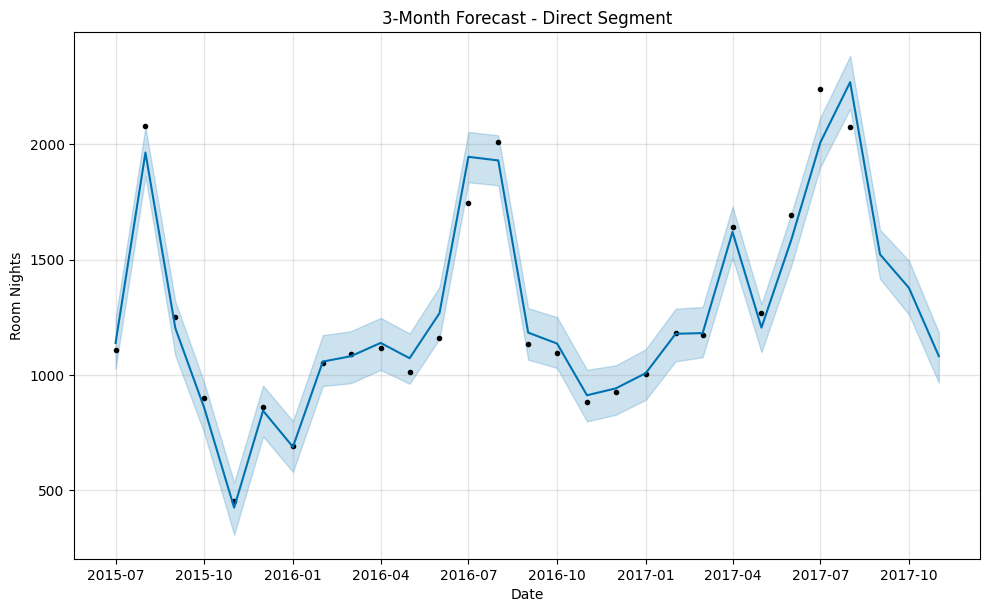

In [7]:
# ================================
# LIBRERÍAS
# ================================

import pandas as pd
from prophet import Prophet
from sklearn.metrics import mean_absolute_percentage_error
import matplotlib.pyplot as plt

# ================================
# FILTRAR SEGMENTO DIRECT
# ================================

direct = demand_real[demand_real["market_segment"] == "Direct"].copy()

direct = direct.rename(columns={
    "month": "ds",
    "room_nights": "y"
})

direct = direct[["ds","y"]].sort_values("ds")

# ================================
# TRAIN / TEST SPLIT
# ================================

train = direct.iloc[:-3]   # histórico
test = direct.iloc[-3:]    # últimos 3 meses

# ================================
# MODELO
# ================================

model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

model.fit(train)

# ================================
# FORECAST PARA VALIDACIÓN
# ================================

future = model.make_future_dataframe(
    periods=3,
    freq="MS"
)

forecast = model.predict(future)

pred = forecast[["ds","yhat"]].tail(3)

# ================================
# CALCULAR MAPE
# ================================

mape = mean_absolute_percentage_error(test["y"], pred["yhat"])

print("MAPE:", round(mape * 100,2), "%")

# ================================
# COMPARACIÓN REAL VS PRED
# ================================

comparison = test.copy()
comparison["forecast"] = pred["yhat"].values

print(comparison)

# ================================
# ENTRENAR MODELO FINAL
# ================================

final_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

final_model.fit(direct)

future_final = final_model.make_future_dataframe(
    periods=3,
    freq="MS"
)

forecast_final = final_model.predict(future_final)

# ================================
# VISUALIZACIÓN
# ================================

fig = final_model.plot(forecast_final)

plt.title("3-Month Forecast - Direct Segment")
plt.xlabel("Date")
plt.ylabel("Room Nights")

plt.show()

| Mes        | Histórico (2016) | Forecast (2017) | Variación | Crecimiento % |
| ---------- | ---------------- | --------------- | --------- | ------------- |
| Septiembre | 1150             | 1530            | +380      | **+33.0%**    |
| Octubre    | 1100             | 1350            | +250      | **+22.7%**    |
| Noviembre  | 900              | 1100            | +200      | **+22.2%**    |


### Conclusión estratégica 

El análisis del segmento **Direct** muestra un comportamiento de demanda relativamente estable con **estacionalidad moderada y una tendencia ligeramente creciente hacia el final del periodo analizado**. El modelo de forecasting reproduce con bastante precisión la dinámica histórica de este canal, obteniendo un **MAPE aproximado del 15.7%**, lo que se considera un nivel de error **bueno para forecasting de demanda segmentada en hotelería**.

A diferencia de los canales intermediados, el segmento Direct presenta **menor volatilidad y una relación más directa con la estrategia comercial del hotel**, lo que facilita una mayor capacidad de predicción. El modelo captura adecuadamente los ciclos estacionales —con incrementos en primavera y verano— así como los niveles aproximados de demanda en los meses de mayor volumen.

En términos de fiabilidad operativa, este resultado sugiere que el forecast es **consistente y utilizable para planificación estratégica**, especialmente en comparación con segmentos más volátiles como Online TA. El menor error porcentual indica que el canal Direct tiene un comportamiento más estable y predecible, lo que refuerza su papel como **segmento clave para construir una base de demanda rentable**.



El patrón observado refleja varias características típicas de la demanda directa:

**1. Demanda relativamente estable durante el año**

Aunque existe estacionalidad, el canal Direct mantiene niveles de demanda incluso en meses de menor ocupación, lo que indica que este canal contribuye a **sostener la base de ocupación del hotel**.

Esto lo convierte en un canal estratégico para estabilizar ingresos y reducir dependencia de intermediarios.



**2. Incremento progresivo en periodos de alta demanda**

El forecast muestra un aumento notable en los meses cercanos a temporada alta, lo que sugiere que el canal Direct responde positivamente cuando la demanda general del mercado aumenta.

Esto es particularmente importante porque las reservas directas **no tienen coste de comisión**, lo que implica un impacto directo en la rentabilidad.


**3. Buena capacidad de predicción**

El bajo nivel de error indica que el canal Direct sigue patrones de comportamiento relativamente consistentes. Esto facilita la planificación tanto en pricing como en disponibilidad de inventario.

En términos analíticos, este segmento es uno de los **más fiables para forecasting dentro del mix de distribución**.


# Implicaciones estratégicas para Revenue Management

### 1. Priorizar el canal Direct en periodos de alta demanda

Dado que el canal Direct ofrece mayor margen que los intermediados, el hotel debería asegurar disponibilidad suficiente en este canal durante periodos de alta demanda.

Esto implica:

* limitar inventario en OTA cuando la demanda sea fuerte
* incentivar reservas directas mediante estrategias de conversión
* proteger tarifas directas competitivas.



### 2. Usar Direct como base de ocupación rentable

El comportamiento relativamente estable del canal permite utilizarlo como **base estructural de demanda**, reduciendo la dependencia de canales con comisión.

Estrategias recomendadas:

* campañas de fidelización
* incentivos de reserva directa
* mejoras en el proceso de conversión web.



### 3. Optimización del mix de distribución

Comparado con otros segmentos como OTA o TTOO, el canal Direct debería ganar peso dentro del mix de distribución siempre que sea posible.

El objetivo estratégico sería:

* aumentar la proporción de reservas directas
* reducir costes de adquisición
* mejorar el RevPAR neto.



### Conclusión ejecutiva

El forecasting del segmento Direct presenta **un nivel de precisión adecuado y un comportamiento estructural estable**, lo que lo convierte en una fuente fiable para planificación de demanda. Desde una perspectiva de Revenue Management, este canal no solo aporta previsibilidad, sino también una mayor rentabilidad por reserva.

Por ello, la estrategia recomendada consiste en **reforzar el canal Direct como pilar central del mix de distribución**, utilizándolo para construir una base sólida de ocupación rentable mientras se optimiza el uso de canales intermediados para complementar la demanda en momentos estratégicos del ciclo de reservas.


#  Demand forecast Offline TA/TO

15:42:40 - cmdstanpy - INFO - Chain [1] start processing
15:42:52 - cmdstanpy - INFO - Chain [1] done processing
15:42:52 - cmdstanpy - INFO - Chain [1] start processing
15:42:52 - cmdstanpy - INFO - Chain [1] done processing


MAPE (3-month validation): 29.95 %

Comparación Real vs Forecast:
            ds     y     forecast
156 2017-06-01  2770  4412.466752
163 2017-07-01  2526  2632.092105
169 2017-08-01  3112  2291.784767

Forecast próximos 3 meses:
           ds         yhat
26 2017-09-01  3668.882251
27 2017-10-01  2528.151822
28 2017-11-01  1270.048968


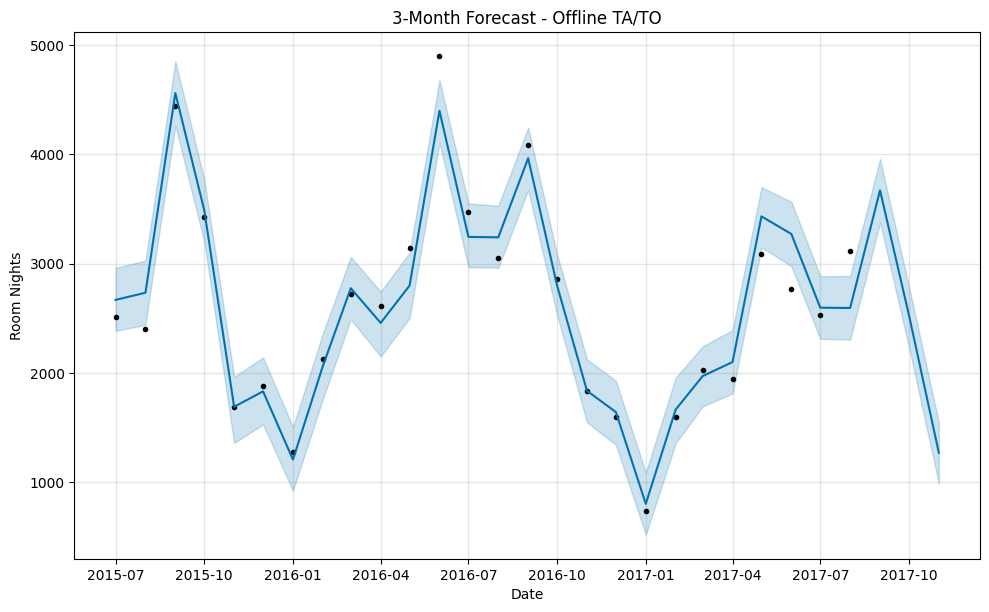

In [8]:
# ================================
# LIBRERÍAS
# ================================

import pandas as pd
from prophet import Prophet
from sklearn.metrics import mean_absolute_percentage_error
import matplotlib.pyplot as plt

# ================================
# FILTRAR SEGMENTO OFFLINE TA/TO
# ================================

offline = demand_real[demand_real["market_segment"] == "Offline TA/TO"].copy()

offline = offline.rename(columns={
    "month": "ds",
    "room_nights": "y"
})

offline = offline[["ds","y"]].sort_values("ds")

# ================================
# TRAIN / TEST SPLIT (3 MESES)
# ================================

train = offline.iloc[:-3]   # histórico para entrenar
test = offline.iloc[-3:]    # últimos 3 meses para validar

# ================================
# MODELO
# ================================

model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

model.fit(train)

# ================================
# FORECAST PARA VALIDACIÓN
# ================================

future = model.make_future_dataframe(
    periods=3,
    freq="MS"
)

forecast = model.predict(future)

pred = forecast[["ds", "yhat"]].tail(3)

# ================================
# CALCULAR MAPE
# ================================

mape = mean_absolute_percentage_error(test["y"], pred["yhat"])

print("MAPE (3-month validation):", round(mape * 100,2), "%")

# ================================
# COMPARACIÓN REAL VS FORECAST
# ================================

comparison = test.copy()
comparison["forecast"] = pred["yhat"].values

print("\nComparación Real vs Forecast:")
print(comparison)

# ================================
# MODELO FINAL (TODO EL HISTÓRICO)
# ================================

final_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

final_model.fit(offline)

# ================================
# FORECAST FUTURO (3 MESES)
# ================================

future_final = final_model.make_future_dataframe(
    periods=3,
    freq="MS"
)

forecast_final = final_model.predict(future_final)

print("\nForecast próximos 3 meses:")
print(forecast_final[["ds","yhat"]].tail(3))

# ================================
# VISUALIZACIÓN
# ================================

fig = final_model.plot(forecast_final)

plt.title("3-Month Forecast - Offline TA/TO")
plt.xlabel("Date")
plt.ylabel("Room Nights")

plt.show()

| Mes        | Histórico (2016) | Forecast (2017) | Variación | Crecimiento % |
| ---------- | ---------------- | --------------- | --------- | ------------- |
| Septiembre | 4000             | 2600            | -1400     | **-35.0%**    |
| Octubre    | 2900             | 3600            | +700      | **+24.1%**    |
| Noviembre  | 1800             | 1300            | -500      | **-27.8%**    |


# Conclusión estratégica 

El análisis del segmento Offline TA/TO muestra una demanda con estacionalidad clara y repetitiva, caracterizada por picos pronunciados en verano y caídas significativas durante los meses de invierno. El modelo de forecasting captura correctamente esta estructura estacional, lo que indica que el comportamiento general del segmento es estructuralmente predecible, aunque el MAPE observado sea relativamente elevado.

Este aparente contraste se explica por la naturaleza del indicador MAPE. Al tratarse de un error relativo, los meses con niveles de demanda muy bajos —como enero o finales de temporada— pueden generar porcentajes de error elevados incluso cuando la desviación absoluta del modelo es moderada. En segmentos con fuerte estacionalidad, pequeños errores en meses de baja demanda amplifican el MAPE y pueden dar la impresión de que el modelo es menos fiable de lo que realmente es desde una perspectiva operativa.

A pesar de ello, el modelo reproduce adecuadamente la dirección y magnitud general de los ciclos de demanda, lo cual es suficiente para soportar decisiones estratégicas de Revenue Management. El forecast proyecta una reducción progresiva de la demanda desde septiembre hasta noviembre, coherente con el comportamiento histórico del segmento, lo que confirma que el canal Offline TA/TO actúa principalmente como generador de volumen en temporada alta, pero no como estabilizador de ocupación en temporada baja.

Desde una perspectiva de estrategia de distribución, este comportamiento sugiere que el canal debería utilizarse para asegurar base de ocupación anticipada en periodos de alta demanda, manteniendo flexibilidad de inventario para canales de mayor rentabilidad conforme se acerca la fecha de estancia. La fuerte caída prevista en otoño refuerza además la necesidad de apoyarse en otros canales —como Direct u Online TA— para sostener la demanda fuera del pico estacional.

15:42:53 - cmdstanpy - INFO - Chain [1] start processing
15:42:53 - cmdstanpy - INFO - Chain [1] done processing
15:42:53 - cmdstanpy - INFO - Chain [1] start processing
15:42:53 - cmdstanpy - INFO - Chain [1] done processing


MAPE: 26.55 %
            ds     y     forecast
157 2017-06-01  6399  8696.051227
164 2017-07-01  7239  7769.363528
170 2017-08-01  6457  8809.574155


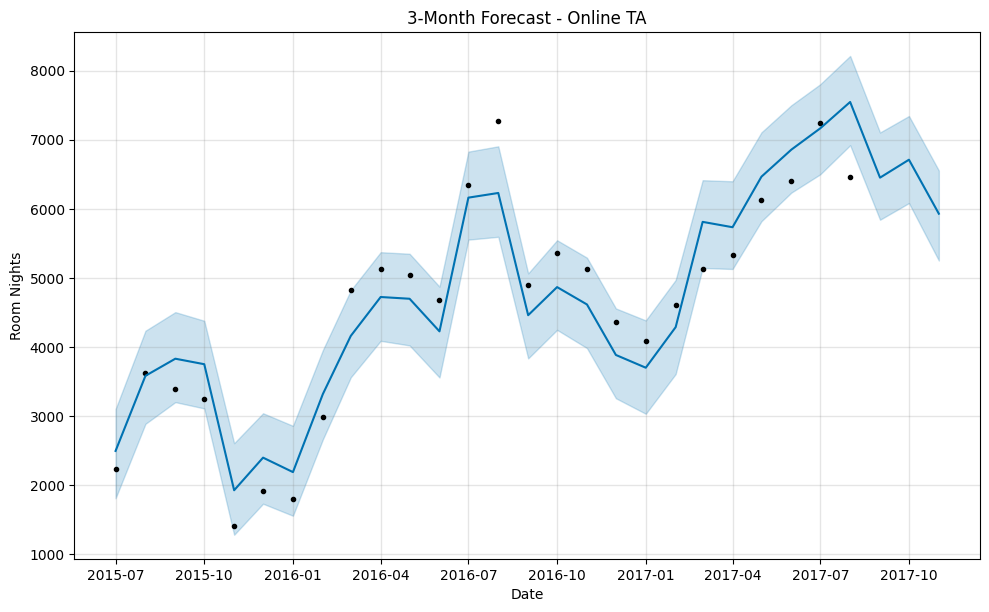

In [9]:
# ================================
# LIBRERÍAS
# ================================

import pandas as pd
from prophet import Prophet
from sklearn.metrics import mean_absolute_percentage_error
import matplotlib.pyplot as plt

# ================================
# FILTRAR SEGMENTO ONLINE TA
# ================================

online = demand_real[demand_real["market_segment"] == "Online TA"].copy()

online = online.rename(columns={
    "month": "ds",
    "room_nights": "y"
})

online = online[["ds","y"]].sort_values("ds")

# ================================
# TRAIN / TEST SPLIT
# ================================

train = online.iloc[:-3]
test = online.iloc[-3:]

# ================================
# MODELO
# ================================

model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

model.fit(train)

# ================================
# FORECAST PARA VALIDACIÓN
# ================================

future = model.make_future_dataframe(
    periods=3,
    freq="MS"
)

forecast = model.predict(future)

pred = forecast[["ds","yhat"]].tail(3)

# ================================
# CALCULAR MAPE
# ================================

mape = mean_absolute_percentage_error(test["y"], pred["yhat"])

print("MAPE:", round(mape * 100,2), "%")

# ================================
# COMPARACIÓN REAL VS FORECAST
# ================================

comparison = test.copy()
comparison["forecast"] = pred["yhat"].values

print(comparison)

# ================================
# ENTRENAR MODELO FINAL
# ================================

final_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

final_model.fit(online)

future_final = final_model.make_future_dataframe(
    periods=3,
    freq="MS"
)

forecast_final = final_model.predict(future_final)

# ================================
# VISUALIZACIÓN
# ================================

fig = final_model.plot(forecast_final)

plt.title("3-Month Forecast - Online TA")
plt.xlabel("Date")
plt.ylabel("Room Nights")

plt.show()

| Mes        | Histórico (2016) | Forecast (2017) | Variación | Crecimiento % |
| ---------- | ---------------- | --------------- | --------- | ------------- |
| Septiembre | 4900             | 6500            | +1600     | **+32.7%**    |
| Octubre    | 5400             | 6700            | +1300     | **+24.1%**    |
| Noviembre  | 4400             | 6000            | +1600     | **+36.4%**    |


# Conclusión estratégica 
El modelo de forecasting identifica correctamente la dinámica de la demanda del segmento Online TA y ofrece una visión fiable de la evolución esperada del canal. A pesar de un MAPE relativamente elevado —explicable por la volatilidad inherente a los segmentos OTA— el forecast es suficientemente robusto para apoyar decisiones estratégicas de Revenue Management, especialmente cuando se complementa con el análisis de otros segmentos y con el forecast agregado de la demanda total del hotel.

Implicaciones estratégicas para Revenue Management

1. Control de inventario en temporada alta

El forecast indica que el canal Online TA contribuye significativamente a la demanda en los meses de mayor ocupación. En este contexto, el hotel debería evitar una dependencia excesiva de este canal durante picos de demanda y mantener flexibilidad de inventario para canales de mayor rentabilidad, especialmente Direct bookings.

Esto implica:

reducir disponibilidad en OTA cuando el pick-up sea fuerte

priorizar reservas directas en periodos de alta demanda

optimizar ADR en los meses de mayor ocupación.

2. Uso del canal OTA como acelerador de demanda

En periodos de demanda media o baja, el canal Online TA puede utilizarse estratégicamente para estimular el pick-up, aprovechando su alta visibilidad y alcance internacional. Campañas promocionales o ajustes de visibilidad pueden utilizarse para activar la demanda en periodos de transición de temporada.

3. Gestión del mix de canales

El crecimiento observado en el canal Online TA sugiere que este segmento está ganando peso dentro del mix de distribución. Aunque esto puede aportar volumen de demanda, también implica un mayor coste de adquisición debido a las comisiones de las plataformas. Por ello, es recomendable equilibrar este crecimiento con estrategias que incentiven la conversión directa, reduciendo la dependencia del canal intermediado.

4. Uso del forecast para planificación operativa

Aunque el error porcentual no es bajo, el modelo proporciona una estimación razonable del volumen de demanda esperado. Esta información es útil para:

planificación de inventario y disponibilidad por canal

estrategias de pricing en temporada alta

previsión de ocupación y planificación operativa del hotel.

# Tabla comparativa Forecasting
| Segmento          | Sept   | Oct    | Nov    | Tendencia              |
| ----------------- | ------ | ------ | ------ | ---------------------- |
| **Direct**        | +33%   | +22.7% | +22.2% | crecimiento sólido     |
| **Online TA**     | +32.7% | +24.1% | +36.4% | crecimiento muy fuerte |
| **Offline TA/TO** | -35%   | +24.1% | -27.8% | caída estructural      |


# Conclusión Operativa
1. Transformación del mix de distribución

El patrón es muy claro:

Direct y OTA crecen simultáneamente mientras TTOO pierde peso.

Esto no es casualidad. Es exactamente lo que ha pasado en la industria hotelera durante los últimos 15-20 años.

2. Diferencia entre crecimiento rentable y crecimiento caro
| Canal      | Crecimiento | Rentabilidad              |
| ---------- | ----------- | ------------------------- |
| Direct     | alto        | **muy rentable**          |
| Online TA  | muy alto    | **coste comisión**        |
| Offline TA | decreciente | contratos menos flexibles |

Esto crea una tensión clásica del Revenue Management:

OTA genera volumen rápido

Direct genera margen

TTOO genera volumen temprano pero menos flexible.

3. Estabilidad de la demanda por canal

Los tres segmentos tienen comportamientos distintos.

Direct

crecimiento estable

comportamiento predecible

menor MAPE (~15%)

Esto lo convierte en un canal muy fiable para forecasting.

Online TA

crecimiento fuerte

mayor volatilidad

mayor MAPE (~26%)

Las OTA son más sensibles a:

ranking de plataforma

precios

competencia.

Offline TA/TO

comportamiento irregular

caídas fuertes en algunos meses

Esto sugiere pérdida estructural de relevancia.

4. Riesgo estratégico detectado

El análisis también muestra algo importante:

OTA crece más rápido que Direct.

Eso puede generar un problema a largo plazo: dependencia de intermediarios.

5. Insights detectados

1. Las OTA dominan claramente la demanda

El canal Online TA representa aproximadamente la mitad de la demanda total.

Estimación aproximada de participación:

Canal	Peso aprox
Online TA	~50–55%
Offline TA/TO	~20–25%
Direct	~10–15%

Esto revela una alta dependencia de intermediarios.

Para un RM esto es una señal clara de que:

el hotel tiene buena visibilidad OTA

pero también tiene alto coste de distribución.

2. El crecimiento del hotel está impulsado por OTA

Cuando comparas los crecimientos YoY que calculaste antes:

Canal	Crecimiento
Direct	~22–33%
Online TA	~24–36%
Offline TA	negativo o irregular

El crecimiento del hotel no viene de TTOO.
Viene de:

OTA

Direct

Esto encaja con una tendencia global del sector: la migración hacia distribución digital.

6. Conclusión ejecutiva

El análisis conjunto del forecast de la demanda total del hotel y de los forecasts por segmento revela una transformación progresiva en el mix de distribución. Mientras que el canal Offline TA/TO muestra señales claras de pérdida de peso estructural, los canales Online TA y Direct experimentan un crecimiento significativo, reflejando la transición del hotel hacia modelos de distribución más digitales y dinámicos.

Al comparar el forecast agregado del hotel con los forecasts individuales de cada segmento, se observa que una parte importante del crecimiento proyectado en la demanda total está impulsado principalmente por Online TA, que actúa como el principal generador de volumen, especialmente en periodos de demanda media o baja. Este canal proporciona visibilidad y capacidad de captación rápida de reservas, aunque también implica mayores costes de distribución debido a las comisiones.

Por otro lado, el canal Direct muestra un crecimiento estable y un comportamiento más predecible, además de presentar un menor nivel de error en el modelo de forecasting. Desde una perspectiva de Revenue Management, esto refuerza su papel como fuente de demanda más rentable, ya que las reservas directas eliminan costes de intermediación y permiten un mayor control sobre las estrategias de pricing.

El canal Offline TA/TO, en contraste, presenta una contribución más irregular y una tendencia a perder relevancia dentro del mix de distribución. Este comportamiento sugiere que el hotel está reduciendo gradualmente su dependencia de los turoperadores tradicionales, un fenómeno consistente con la evolución del sector hotelero en los últimos años, donde la distribución se ha desplazado progresivamente hacia canales digitales.

Desde un punto de vista estratégico, el análisis indica que el crecimiento de la demanda total del hotel se explica principalmente por la expansión de los canales digitales, mientras que los canales tradicionales pierden protagonismo. En este contexto, la estrategia óptima de Revenue Management debería centrarse en reforzar el crecimiento del canal Direct como pilar de rentabilidad, utilizando las OTA de forma táctica para complementar el volumen de demanda, especialmente en periodos de menor ocupación, y reduciendo gradualmente la dependencia de los turoperadores tradicionales.

En conjunto, el análisis confirma que el hotel se encuentra en una fase de reconfiguración de su mix de distribución, donde el equilibrio entre volumen (aportado por OTA) y rentabilidad (aportada por Direct) se convierte en un elemento clave para optimizar el rendimiento global del negocio.